# Project: Part2 - Create Dashboard with Plotly and Dash Using Automobile Sales During Recession Dataset

<b>Keman Xiang</b>

## Table of content

- Project Overview
- Components of the report items
- Dataset Variables
- Dashboard Structure
- Create the Application
- Complete Code
- Final Output (images)

# Project Overview
<b>Analyzing the Impact of Recession on Automobile Sales</b> \
Assume that we have been hired by XYZAutomotives as a data scientist. Our first task is to analyze the historical data and give the company directors insights on how the sales were affected during times of recession. We will provide a number of charts/plots to visualize the data and make it easy for the directors to understand our analysis.

This Project will be completed in 2 Parts:
- Part 1: Create Visualizations using Matplotlib, Seaborn & Folium
- Part 2: Create Dashboard using Plotly and Dash

## Part 2: Create Dashboard using Plotly and Dash
### Objective
The objective of this part of the project is to create dashboards to contain our plots and charts and to provide the directors with the ability to select a particular report or a period of time so they can discuss the data in detail.

In this part we will create **Dashboards** using <u>*Dash and Plotly*</u> and then add user-interactions to our dashboards. As a data scientist, we have been given a task to prepare a report on our finding from Automobile Sales data analysis. 

We decided to develop a dashboard representing two main reports:-

   - Yearly Automobile Sales Statistics
   - Recession Period Statistics

_NOTE:_ Year range is between 1980 and 2013.


### Creating dashboards and adding customizations to the dashboards
The directors of XYZAutomobiles have requested a dashboard to be developed so they can drill into the data in more detail for specific years or by different categories. Our second task is to create a suitable dashboard and add in user interactions so that the directors can select the data they want to review without the need to request new plots.

### Tasks to be performed
- TASK 2.1: Create a Dash application and give it a meaningful title.
- TASK 2.2: Add drop-down menus to your dashboard with appropriate titles and options.
- TASK 2.3: Add a division for output display with appropriate id and classname property.
- TASK 2.4: Creating Callbacks; Define the callback function to update the input container based on the selected statistics and the output container.
- TASK 2.5: Create and display graphs for Recession Report Statistics.
- TASK 2.6: Create and display graphs for Yearly Report Statistics.

# Components of the Report Items

**1. Yearly Automobile Sales Statistics**
This report mainly consists of the following items:
- **Yearly Automobile Sales Using Line Chart for the Whole Period (line chart)**:This line chart displays the average automobile sales for each year across the entire period.
- **Total Monthly Automobile Sales Using Line Chart (line chart)**:This line chart displays the total monthly automobile sales for the selected year.
- **Average Vehicles Sold by Vehicle Type in the Selected Year (bar chart)**:This bar chart shows the average number of vehicles sold for each vehicle type in the selected year.
- **Total Advertisement Expenditure for Each Vehicle Using Pie Chart (pie chart)**:
This pie chart represents the total advertising expenditure for each vehicle type in the selected year.
   
**2. Recession Period Statistics**
  - **Average Automobile Sales Fluctuation Over Recession Period (Year-wise)**:This line chart shows the average automobile sales for each year during recession periods.
   - **Average Number of Vehicles Sold by Vehicle Type**:This bar chart displays the average number of vehicles sold for each vehicle type during recession periods.   
   - **Total Expenditure Share by Vehicle Type During Recessions**:This pie chart represents the total advertising expenditure share by vehicle type during recession periods.
   - **Effect of Unemployment Rate on Vehicle Type and Sales**:This bar chart shows the effect of unemployment rate on automobile sales by vehicle type during recession periods.

# Data Description

The dataset used for this visualization project contains *automobile_sales* data representing automobile sales and related variables during recession and non-recession period. 

The dataset includes the following variables:
<br><b>1. Date:</b> The month end date of sales observation.
<br><b>2. Recession: </b>A binary variable indicating recession perion; 1 means it was recession, 0 means it was normal.
<br><b>3. Automobile_Sales:</b> The number of vehicles sold during the period.
<br><b>4. GDP:</b> The per capita GDP value in USD.
<br><b>5. Unemployment_Rate:</b> The monthly unemployment rate.
<br><b>6. Consumer_Confidence:</b> A synthetic index representing consumer confidence, which can impact consumer spending and automobile purchases.
<br><b>7. Seasonality_Weight:</b> The weight representing the seasonality effect on automobile sales during the period. This variable represents the seasonal effect on automobile sales for a given month. In the automobile industry, sales often fluctuate throughout the year due to seasonal patterns—for example, sales may increase during the festive season or year-end promotions, and decrease during off-peak months like post-holiday winter periods.
- A value greater than 1 indicates higher-than-average sales expected for that month due to seasonal trends (e.g., holiday season or new model launches).
- A value less than 1 suggests lower-than-average sales due to seasonal slowdowns.
- A value around 1 means the season has neutral or average effect on sales.

<b>8. Price:</b> The average vehicle price during the period.
<br><b>9. Advertising_Expenditure:</b> The advertising expenditure of the company.
<br><b>10.Vehicle_Type:</b> The type of vehicles sold; Supperminicar, Smallfamiliycar,Mediumfamilycar, Executivecar, Sports.
<br><b>11.Competition:</b> The measure of competition in the market, such as the number of competitors or market share of major manufacturers.
<br><b>12.Month:</b> Month of the observation extracted from Date..
<br><b>13.Year:</b> Year of the observation extracted from Date.
<br>
By examining various factors mentioned above from the dataset, we aim to gain insights into how recessions impacted automobile sales for our company.


# Dashboard Structure

1. **Dropdown Menus**:
We will be creating two dropdown menus:
- The first dropdown allows selection of the report type (Yearly Statistics or Recession Period Statistics).
- The second dropdown is for selecting the year. This should be enabled only when the user selects `Yearly Statistics report` and will be disabled if `Recession Period Statistics` is selected.
Each dropdown will be placed within a separate division.
 
2. **App Layout**: This define the layout of the app, including titles, dropdown menus, and containers for displaying output.

3. **Callback functions for Interactivity**:

   - **Callback for Updating Input Container:**
		<p>Here we define a callback function to update the input container based on the selected statistics.</p>
        
        ***The purpose of this function is to control the state (enabled or disabled) of the year dropdown based on the user\'s selection of the report type.***
	  
      Specifically:
         - Enabled (returns True) when `Yearly Statistics` is selected, allowing the                user to choose a year.
         - Disabled (returns False) when `Recession Period Statistics` is selected, preventing the user from selecting a year because it is irrelevant in the context of recession statistics.

    -  **Callback for Plotting:**
        <p>Here we define another callback functions to update the output container based on selected statistics and year, creating various plots for the dashboard.</p>
      The four plots will be displayed in 2 rows, 2 column representation


# Let's create the application

In [1]:
#import libraries
import dash
import more_itertools
from dash import dcc
from dash import html
from dash.dependencies import Input, Output
import pandas as pd
import plotly.graph_objs as go
import plotly.express as px

In [2]:
# Load the data using pandas
data = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/d51iMGfp_t0QpO30Lym-dw/automobile-sales.csv')
data.head()

,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1980-01-31,1980,Jan,1,108.24,0.45,27704,1417.5,7,60.22,0.01,5.4,220.0,SmallFamilyCar,Georgia
1,1980-01-31,1980,Jan,1,108.24,0.45,77270,763.7,7,60.22,0.01,5.4,72.0,Sports,Georgia
2,1980-01-31,1980,Jan,1,108.24,0.36,19665,1417.5,7,60.22,0.01,5.4,238.0,SuperMiniCar,Georgia
3,1980-01-31,1980,Jan,1,108.24,0.38,36986,1417.5,7,60.22,0.01,5.4,224.0,MediumFamilyCar,Georgia
4,1980-02-29,1980,Feb,1,98.75,0.46,26609,2773.4,4,45.99,-0.31,4.8,280.0,SmallFamilyCar,New York


In [3]:
# Initialize the Dash app
app = dash.Dash(__name__)

In [4]:
#---------------------------------------------------------------------------------
#Start With Basic Settings:
# Create the dropdown menu options
dropdown_options = [
    {'label': 'Yearly Statistics', 'value': 'Yearly Statistics'},
    {'label': 'Recession Period Statistics', 'value': 'Recession Period Statistics'}
]
# List of years 
year_list = [i for i in range(1980, 2024, 1)]

##  Create the layout of the app

### TASK 2.1: Let's first design the layout, starting with a meaningful title

In [ ]:
'''
app.layout = html.Div([
    #TASK 2.1 Add title to the dashboard
    html.H1("Automobile Sales Statistics Dashboard",style={'textAlign': 'center', 'color': '#503D36', 'font-size': 24}),#Include style for title
'''

### TASK 2.2: Add drop-down menus to the dashboard with appropriate titles and options

#### Select Report-type Dropdown
Create a dropdown menu and add two ***Report*** options to it.

Parameters to be updated in `dcc.Dropdown`:
- Let's set id to `dropdown-statistics`.
- Set options to a **list containing dictionaries** with label and user-provided values for value.
- Set placeholder to `Select a report type`.
- Set value to `Select Statistics`.
- Set style

In [ ]:
#TASK 2.2: Add two dropdown menus - Report-type Dropdown
'''
    html.Div([
        html.Label("Select Statistics:"),
        dcc.Dropdown(
            id='dropdown-statistics',
            options=[{'label': 'Yearly Statistics', 'value': 'Yearly Statistics'},
                    {'label': 'Recession Period Statistics', 'value': 'Recession Period Statistics'}],
            value='Select Statistics',
            placeholder='Select a report type',
            style={'width':'80%','padding':'3px','font-size':'20px','testAlignLast':'center'}
        )
    ]),
'''

#### Select Year Dropdown
Create a dropdown menu for selecting the ***YEAR*** options to it.
Here we pass a list of years as options in this dropdown: ***[year_list = [i for i in range(1980, 2024, 1)]]***

Parameters to be updated in `dcc.Dropdown`:
- Set id to `select-year`
- Set value to `Select-year`
- Set placeholder to `Select-year`

In [ ]:
#TASK 2.2: Add two dropdown menus - Year Dropdown
'''
html.Div(dcc.Dropdown(
            id='select-year',
            options=[{'label': i, 'value': i} for i in year_list],
            value='Select-year',
            placeholder='Select-year',
            style={'width':'80%','padding':'3px','font-size':'20px','testAlignLast':'center'}
        )),
'''

### TASK 2.3: Add a division for output display with appropriate id and classname property
Add an inner division to display the output
We will pass the plots as returned by the callback function into this `output-container` later refering to the class name of it.

Parameters:
- Set id to `output-container`.
- Set className to `chart-grid`
- Set style to be displayed as a `flex`

In [ ]:
#TASK 2.3: Add a division for output display
'''
html.Div([
        html.Div(id='output-container', className='chart-grid', style={'display': 'flex'}),])
])
'''

### TASK 2.4: Creating Callbacks
<b>Define the callback function to update the input container based on the selected statistics and the output container.</b>

#### Update Input Container callback function
The purpose of this function is to enable or disable the year selection dropdown based on the user\'s choice of report type from another dropdown.\
Here we are having 2 parts:
1. Callback definition:
The parameters of the Callback definition are as follows:
- **Output**: Specifies the output of the callback, which in this case is the `disabled` property of the dropdown with the ID `select-year`.
- **Input**: Specifies the input that triggers the callback, which is the `value` property of the dropdown with the ID `dropdown-statistics`.

2. Callback Function:
-  The function checks the value of selected statistics. If the selected statistics is `Yearly Statistics`  the function returns False. This means the `disabled` property of the select-year dropdown will be set to False, enabling the dropdown so the user can select a year.

-  If selected statistics is not `Yearly Statistics` (i.e., it is `Recession Period Statistics`), the function returns True. This means the `disabled` property of the select-year dropdown will be set to True, disabling the dropdown as selecting a year is not relevant in this context.


In [ ]:
#TASK 2.4: Creating Callbacks
# Define the callback function to update the input container based on the selected statistics
'''
@app.callback(
    Output(component_id='select-year', component_property='disabled'),
    Input(component_id='dropdown-statistics',component_property='value'))

def update_input_container(selected_statistics):
    if selected_statistics =='Yearly Statistics': 
        return False
    else: 
        return True
'''

#### Update Output Container callback function

Our layout has 1 output container, and we will be required to return the plots developed `dcc.Graph()` into this container `as divisions`.
For each report we need to display four plots.

The `update_output_container` function in this Dash application dynamically generates and displays graphs based on the user\'s selection from the dropdown menus. Specifically, it creates different sets of graphs for `Recession Period Statistics` and `Yearly Statistics`. We will be creating 4 plots for each report.

Here we have 2 parts:
1. Callback Definition:
Parameters:
- **Output**:This specifies that the `children` property of the component with the ID `output-container` will be updated.In Dash, children typically refers to the content within a container, such as graphs, text, or other HTML elements.
- **Input**: 
    - **Input Property for Report type**:This specifies that the `value` property of the dropdown menu with the ID `dropdown-statistics` (which allows the user to select between `Yearly Statistics` and `Recession Period Statistics`) will trigger the callback when it changes.
     - **Input property for year selection**: This specifies that the `value` property of the dropdown menu with the ID `select-year` (which allows the user to select a specific year) will trigger the callback when it changes.
 
2. Callback Function:
Here we will filter the data based on the `report type` selected.

When `Recession Period Statistics` is selected, the data is filtered to include only recession periods where `Recession equals 1`. Conversely, when `Yearly Statistics` is chosen, the data is filtered based on the selected year.

In [ ]:
#Callback for plotting
# Define the callback function to update the input container based on the selected statistics
'''
# Callback definition
@app.callback(
     Output(component_id='output-container', component_property='children'),
    [Input(component_id='dropdown-statistics', component_property='value'), 
    Input(component_id='select-year', component_property='value')])

# Callback function
def update_output_container(selected_statistics, input_year):
    if selected_statistics == 'Recession Period Statistics':
        # Filter the data for recession periods
        recession_data = data[data['Recession'] == 1]
        ...... # Some codes are omitted here, we will cover them later in this notebook
    elif (input_year and selected_statistics=='Yearly Statistics') :
        yearly_data = data[data['Year'] == input_year]
        ...... # Some codes are omitted here, we will cover them later in this notebook
    else:
        return None
'''

### TASK 2.5: Create and display graphs for Recession Report Statistics

We will prepare the data using `plotly.express` and use functions as per the plot requirement (eg. using `groupby()`, `sum()` and `mean()` functions depending on the senario).

In [ ]:
#TASK 2.5: Create and display graphs for Recession Report Statistics

'''
#Plot 1 Automobile sales fluctuate over Recession Period (year wise)
        # use groupby to create relevant data for plotting
        yearly_rec=recession_data.groupby('Year')['Automobile_Sales'].mean().reset_index()
        R_chart1 = dcc.Graph(
            figure=px.line(yearly_rec, 
                x='Year',
                y='Automobile_Sales',
                title="Average Automobile Sales fluctuation over Recession Period"))

#Plot 2 Calculate the average number of vehicles sold by vehicle type       
        # use groupby to create relevant data for plotting
        #Hint:Use Vehicle_Type and Automobile_Sales columns
        average_sales = recession_data.groupby('Vehicle_Type')['Automobile_Sales'].mean().reset_index()                 
        R_chart2  = dcc.Graph(
            figure=px.bar(average_sales,
            x='Vehicle_Type',
            y='Automobile_Sales',
            title="Average Number of Vehicles Sold By Vehicle Type"))
        
# Plot 3 Pie chart for total expenditure share by vehicle type during recessions
        # grouping data for plotting
	# Hint:Use Vehicle_Type and Advertising_Expenditure columns
        exp_rec= recession_data.groupby('Vehicle_Type')['Advertising_Expenditure'].sum().reset_index()
        R_chart3 = dcc.Graph(
            figure = px.pie(exp_rec,
            values='Advertising_Expenditure',
            names='Vehicle_Type',
            title='Total Expenditure Share By Vehicle Type During Recessions'
            ))

# Plot 4 bar chart for the effect of unemployment rate on vehicle type and sales
        #grouping data for plotting
	# Hint:Use unemployment_rate,Vehicle_Type and Automobile_Sales columns
        unemp_data = recession_data.groupby(['unemployment_rate','Vehicle_Type'])['Automobile_Sales'].mean().reset_index()
        R_chart4 = dcc.Graph(figure=px.bar(unemp_data,
        x='unemployment_rate',
        y='Automobile_Sales',
        color='Vehicle_Type',
        labels={'unemployment_rate': 'Unemployment Rate', 'Automobile_Sales': 'Average Automobile Sales'},
        title='Effect of Unemployment Rate on Vehicle Type and Sales'))


        return [
             html.Div(className='chart-item', children=[html.Div(children=R_chart1),html.Div(children=R_chart2)],style={'display': 'center'}),
            html.Div(className='chart-item', children=[html.Div(children=R_chart3),html.Div(children=R_chart4)],style={'display': 'center'})
            ]
'''

### TASK 2.6: Create and display graphs for Yearly Report Statistics

We will continue creating plots for the Yearly Report section

In [ ]:
# TASK 2.6: Create and display graphs for Yearly Report Statistics
# Yearly Statistic Report Plots

'''
    # Check for Yearly Statistics.                             
    elif (input_year and selected_statistics=='Yearly Statistics') :
        yearly_data = data[data['Year'] == input_year]
                              
                              
#plot 1 Yearly Automobile sales using line chart for the whole period.
        # grouping data for plotting.
        # Hint:Use the columns Year and Automobile_Sales.
        yas= data.groupby('Year')['Automobile_Sales'].mean().reset_index()
        Y_chart1 = dcc.Graph(figure=px.line(yas,
                                            x='Year',
                                            y='Automobile_Sales',
                                            title='Yearly Automobile Sales'))
            
# Plot 2 Total Monthly Automobile sales using line chart.
        # grouping data for plotting.
	# Hint:Use the columns Month and Automobile_Sales.
        mas=data.groupby('Month')['Automobile_Sales'].sum().reset_index()
        Y_chart2 = dcc.Graph(figure=px.line(mas,
            x='Month',
            y='Automobile_Sales',
            title='Total Monthly Automobile Sales'))

  # Plot bar chart for average number of vehicles sold during the given year
         # grouping data for plotting.
         # Hint:Use the columns Year and Automobile_Sales
        avr_vdata=yearly_data.groupby('Vehicle_Type')['Automobile_Sales'].mean().reset_index()
        Y_chart3 = dcc.Graph(figure=px.bar(avr_vdata,
                                        x='Vehicle_Type',
                                       y='Automobile_Sales',
                                        title='Average Vehicles Sold by Vehicle Type in the year {}'.format(input_year)))

    # Total Advertisement Expenditure for each vehicle using pie chart
         # grouping data for plotting.
         # Hint:Use the columns Vehicle_Type and Advertising_Expenditure
        exp_data=yearly_data.groupby('Vehicle_Type')['Advertising_Expenditure'].sum().reset_index()
        Y_chart4 = dcc.Graph(figure=px.pie(exp_data,
                                            values='Advertising_Expenditure',
                                            names='Vehicle_Type',
                                            title='Total Advertisment Expenditure for Each Vehicle'))

        #Returning the graphs for displaying Yearly data
        return [
                html.Div(className='chart-item', children=[html.Div(children=Y_chart1),html.Div(children=Y_chart2)],style={'display':'center'}),
                html.Div(className='chart-item', children=[html.Div(children=Y_chart3),html.Div(children=Y_chart4)],style={'display': 'center'})
        ]


    else:
        return None
        
# Run the Dash app
if __name__ == '__main__':
    app.run(debug=True,port=8051)
'''

### Finally, here is our complete code:

In [6]:
#import libraries
import dash
import more_itertools
from dash import dcc
from dash import html
from dash.dependencies import Input, Output
import pandas as pd
import plotly.graph_objs as go
import plotly.express as px

# Load the data using pandas
data = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/d51iMGfp_t0QpO30Lym-dw/automobile-sales.csv')

# Initialize the Dash app
app = dash.Dash(__name__)

# Set the title of the dashboard
#app.title = "Automobile Statistics Dashboard"

#---------------------------------------------------------------------------------
# Create the dropdown menu options
dropdown_options = [
    {'label': 'Yearly Statistics', 'value': 'Yearly Statistics'},
    {'label': 'Recession Period Statistics', 'value': 'Recession Period Statistics'}
]
# List of years 
year_list = [i for i in range(1980, 2024, 1)]

#---------------------------------------------------------------------------------------
# Create the layout of the app
app.layout = html.Div([
    #TASK 2.1 Add title to the dashboard
    html.H1("Automobile Sales Statistics Dashboard",style={'textAlign': 'center', 'color': '#503D36', 'font-size': 24}),#Include style for title
    #TASK 2.2: Add two dropdown menus
    html.Div([
        html.Label("Select Statistics:"),
        dcc.Dropdown(
            id='dropdown-statistics',
            options=[{'label': 'Yearly Statistics', 'value': 'Yearly Statistics'},
                    {'label': 'Recession Period Statistics', 'value': 'Recession Period Statistics'}],
            value='Select Statistics',
            placeholder='Select a report type',
            style={'width':'80%','padding':'3px','font-size':'20px','testAlignLast':'center'}
        )
    ]),
    html.Div(dcc.Dropdown(
            id='select-year',
            options=[{'label': i, 'value': i} for i in year_list],
            value='Select-year',
            placeholder='Select-year',
            style={'width':'80%','padding':'3px','font-size':'20px','testAlignLast':'center'}
        )),
    html.Div([#TASK 2.3: Add a division for output display
        html.Div(id='output-container', className='chart-grid', style={'display': 'flex'}),])
])
#TASK 2.4: Creating Callbacks
# Define the callback function to update the input container based on the selected statistics
@app.callback(
    Output(component_id='select-year', component_property='disabled'),
    Input(component_id='dropdown-statistics',component_property='value'))

def update_input_container(selected_statistics):
    if selected_statistics =='Yearly Statistics': 
        return False
    else: 
        return True

#Callback for plotting
# Define the callback function to update the input container based on the selected statistics
@app.callback(
     Output(component_id='output-container', component_property='children'),
    [Input(component_id='dropdown-statistics', component_property='value'), 
    Input(component_id='select-year', component_property='value')])

def update_output_container(selected_statistics, input_year):
    if selected_statistics == 'Recession Period Statistics':
        # Filter the data for recession periods
        recession_data = data[data['Recession'] == 1]
  
#TASK 2.5: Create and display graphs for Recession Report Statistics

#Plot 1 Automobile sales fluctuate over Recession Period (year wise)
        # use groupby to create relevant data for plotting
        yearly_rec=recession_data.groupby('Year')['Automobile_Sales'].mean().reset_index()
        R_chart1 = dcc.Graph(
            figure=px.line(yearly_rec, 
                x='Year',
                y='Automobile_Sales',
                title="Average Automobile Sales fluctuation over Recession Period"))

#Plot 2 Calculate the average number of vehicles sold by vehicle type       
        # use groupby to create relevant data for plotting
        #Hint:Use Vehicle_Type and Automobile_Sales columns
        average_sales = recession_data.groupby('Vehicle_Type')['Automobile_Sales'].mean().reset_index()                 
        R_chart2  = dcc.Graph(
            figure=px.bar(average_sales,
            x='Vehicle_Type',
            y='Automobile_Sales',
            title="Average Number of Vehicles Sold By Vehicle Type"))
        
# Plot 3 Pie chart for total expenditure share by vehicle type during recessions
        # grouping data for plotting
	# Hint:Use Vehicle_Type and Advertising_Expenditure columns
        exp_rec= recession_data.groupby('Vehicle_Type')['Advertising_Expenditure'].sum().reset_index()
        R_chart3 = dcc.Graph(
            figure = px.pie(exp_rec,
            values='Advertising_Expenditure',
            names='Vehicle_Type',
            title='Total Expenditure Share By Vehicle Type During Recessions'
            ))

# Plot 4 bar chart for the effect of unemployment rate on vehicle type and sales
        #grouping data for plotting
	# Hint:Use unemployment_rate,Vehicle_Type and Automobile_Sales columns
        unemp_data = recession_data.groupby(['unemployment_rate','Vehicle_Type'])['Automobile_Sales'].mean().reset_index()
        R_chart4 = dcc.Graph(figure=px.bar(unemp_data,
        x='unemployment_rate',
        y='Automobile_Sales',
        color='Vehicle_Type',
        labels={'unemployment_rate': 'Unemployment Rate', 'Automobile_Sales': 'Average Automobile Sales'},
        title='Effect of Unemployment Rate on Vehicle Type and Sales'))


        return [
             html.Div(className='chart-item', children=[html.Div(children=R_chart1),html.Div(children=R_chart2)],style={'display': 'center'}),
            html.Div(className='chart-item', children=[html.Div(children=R_chart3),html.Div(children=R_chart4)],style={'display': 'center'})
            ]

# TASK 2.6: Create and display graphs for Yearly Report Statistics
 # Yearly Statistic Report Plots
    # Check for Yearly Statistics.                             
    elif (input_year and selected_statistics=='Yearly Statistics') :
        yearly_data = data[data['Year'] == input_year]
                              

                              
#plot 1 Yearly Automobile sales using line chart for the whole period.
        # grouping data for plotting.
        # Hint:Use the columns Year and Automobile_Sales.
        yas= data.groupby('Year')['Automobile_Sales'].mean().reset_index()
        Y_chart1 = dcc.Graph(figure=px.line(yas,
                                            x='Year',
                                            y='Automobile_Sales',
                                            title='Yearly Automobile Sales'))
            
# Plot 2 Total Monthly Automobile sales using line chart.
        # grouping data for plotting.
	# Hint:Use the columns Month and Automobile_Sales.
        mas=data.groupby('Month')['Automobile_Sales'].sum().reset_index()
        Y_chart2 = dcc.Graph(figure=px.line(mas,
            x='Month',
            y='Automobile_Sales',
            title='Total Monthly Automobile Sales'))

  # Plot bar chart for average number of vehicles sold during the given year
         # grouping data for plotting.
         # Hint:Use the columns Year and Automobile_Sales
        avr_vdata=yearly_data.groupby('Vehicle_Type')['Automobile_Sales'].mean().reset_index()
        Y_chart3 = dcc.Graph(figure=px.bar(avr_vdata,
                                        x='Vehicle_Type',
                                       y='Automobile_Sales',
                                        title='Average Vehicles Sold by Vehicle Type in the year {}'.format(input_year)))

    # Total Advertisement Expenditure for each vehicle using pie chart
         # grouping data for plotting.
         # Hint:Use the columns Vehicle_Type and Advertising_Expenditure
        exp_data=yearly_data.groupby('Vehicle_Type')['Advertising_Expenditure'].sum().reset_index()
        Y_chart4 = dcc.Graph(figure=px.pie(exp_data,
                                            values='Advertising_Expenditure',
                                            names='Vehicle_Type',
                                            title='Total Advertisment Expenditure for Each Vehicle'))

#TASK 2.6: Returning the graphs for displaying Yearly data
        return [
                html.Div(className='chart-item', children=[html.Div(children=Y_chart1),html.Div(children=Y_chart2)],style={'display':'center'}),
                html.Div(className='chart-item', children=[html.Div(children=Y_chart3),html.Div(children=Y_chart4)],style={'display': 'center'})
        ]
    else:
        return None

# Run the Dash app
if __name__ == '__main__':
    app.run(debug=True,port=8051)

# Final Output

## 1. Output - Yearly Statistics Selection (1980)
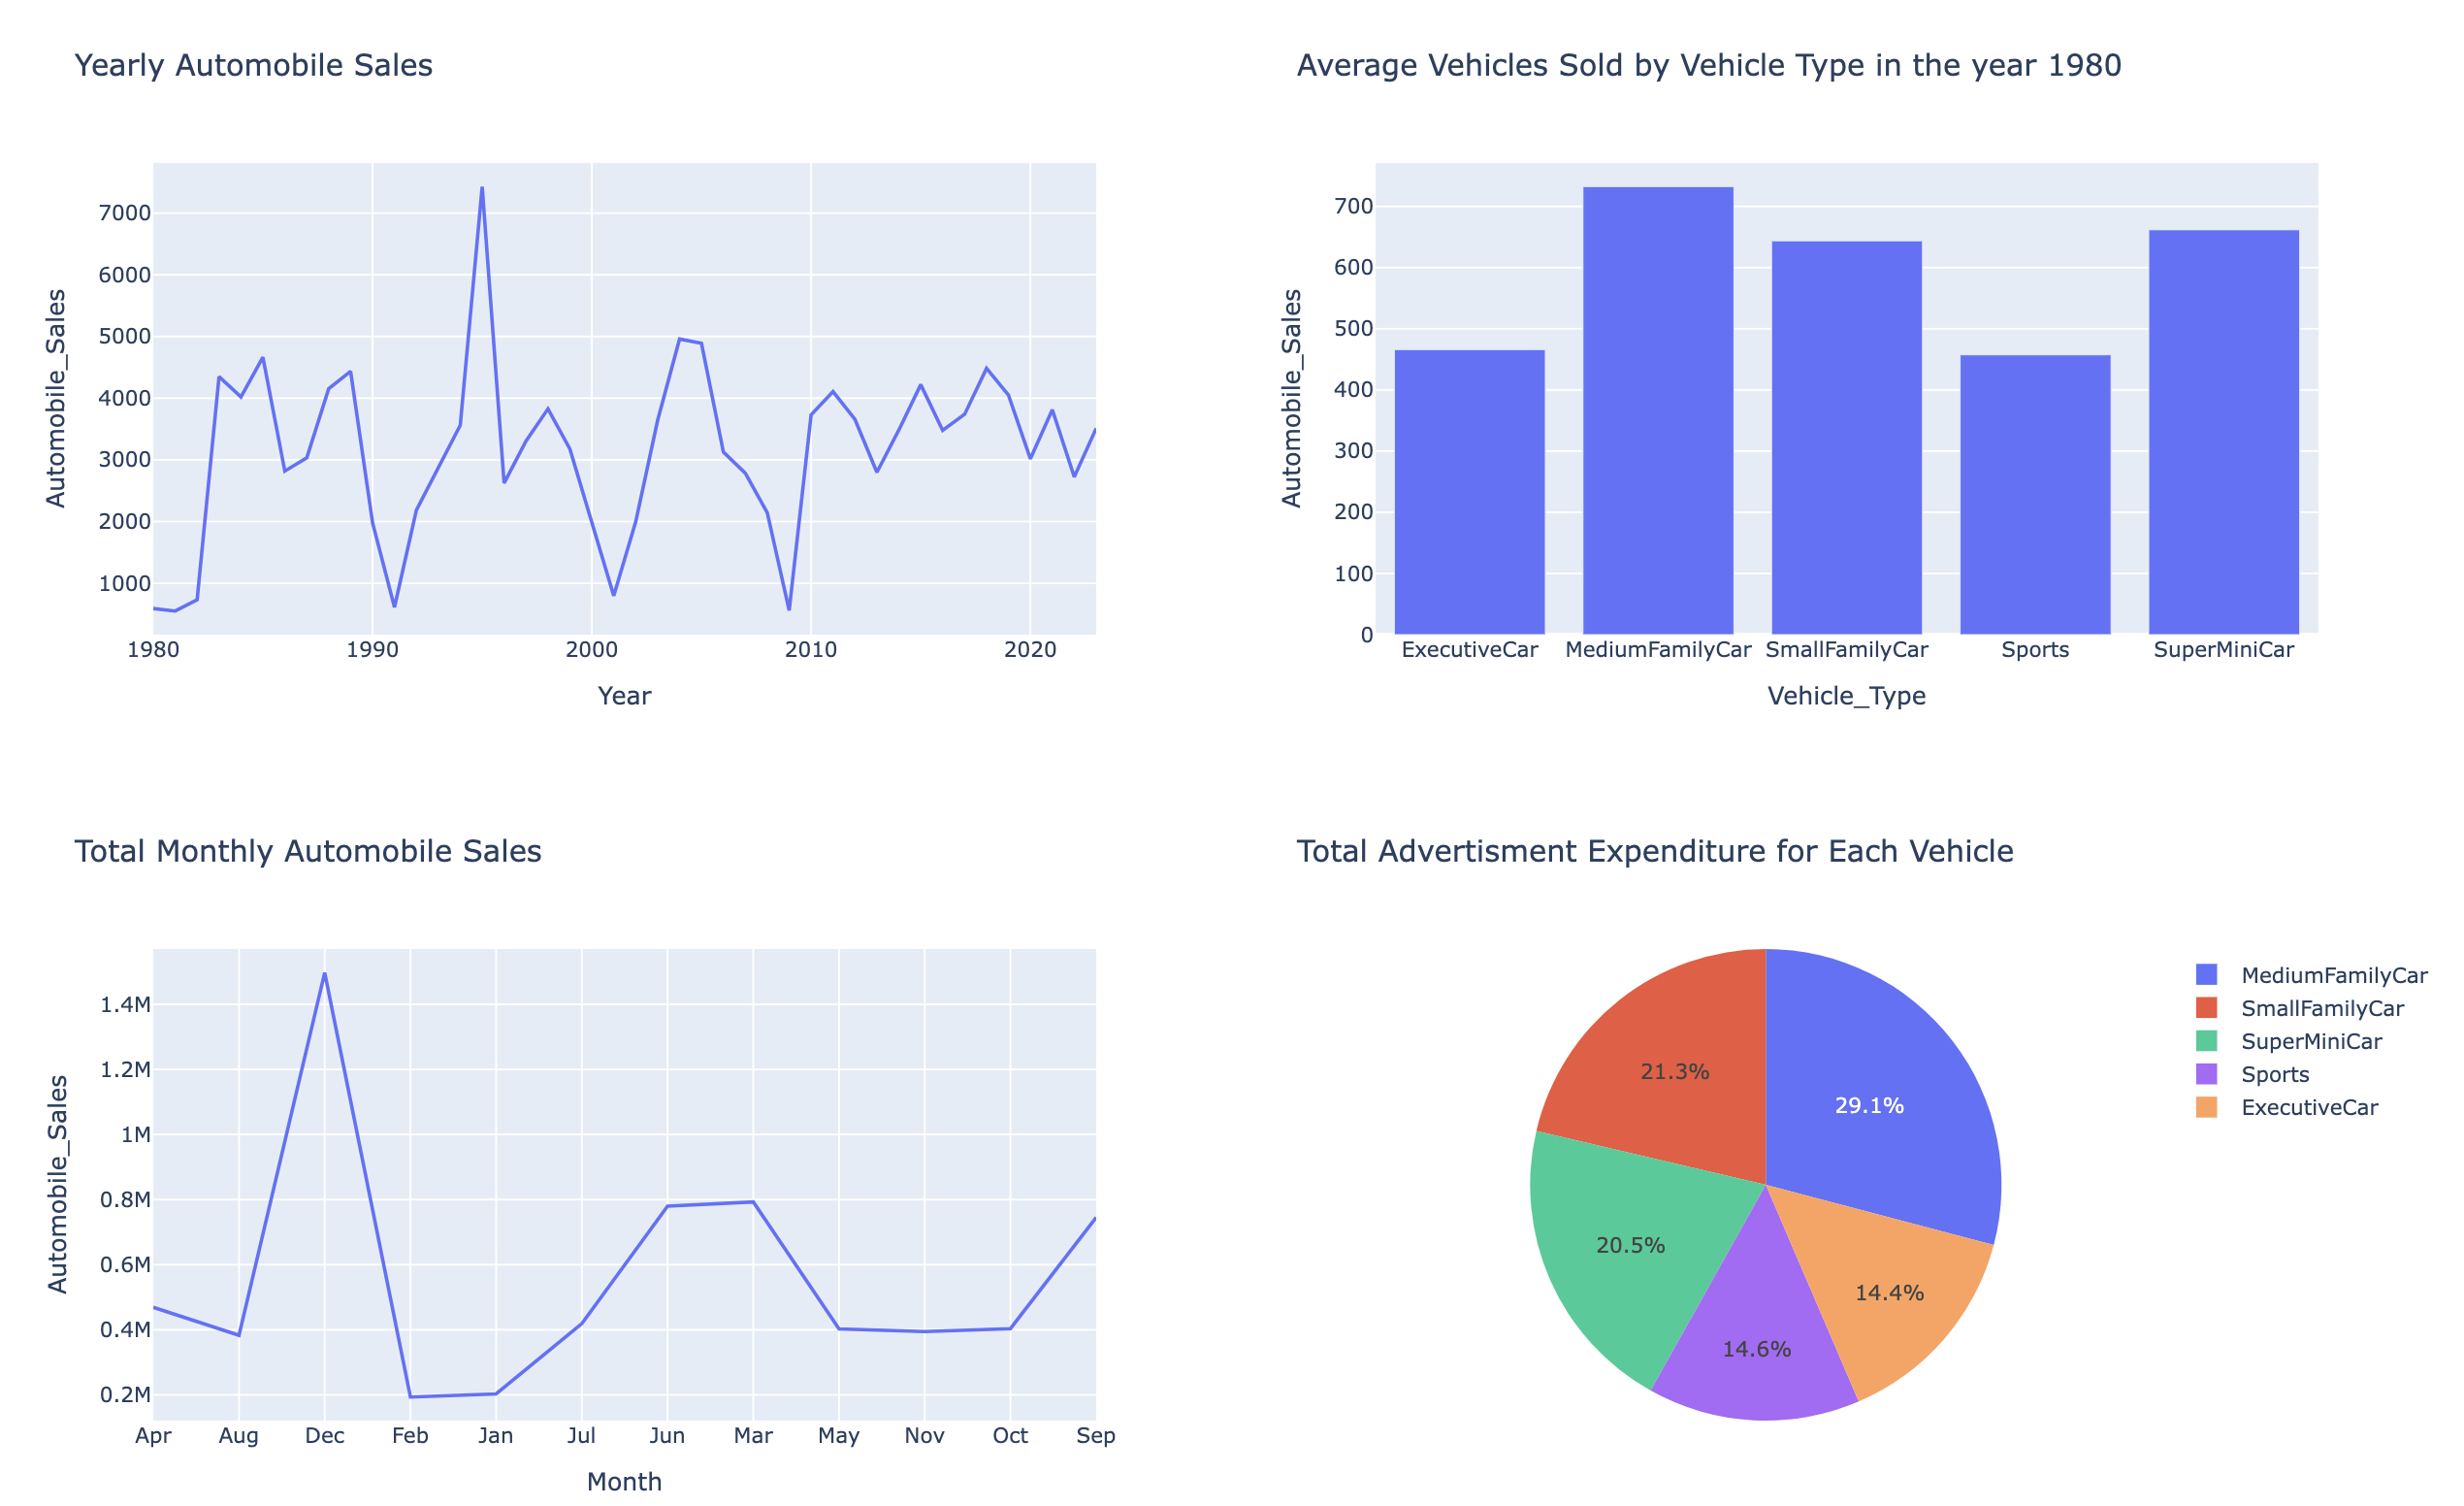

### 1.1 Plot 1 - Yearly Automobile Sales
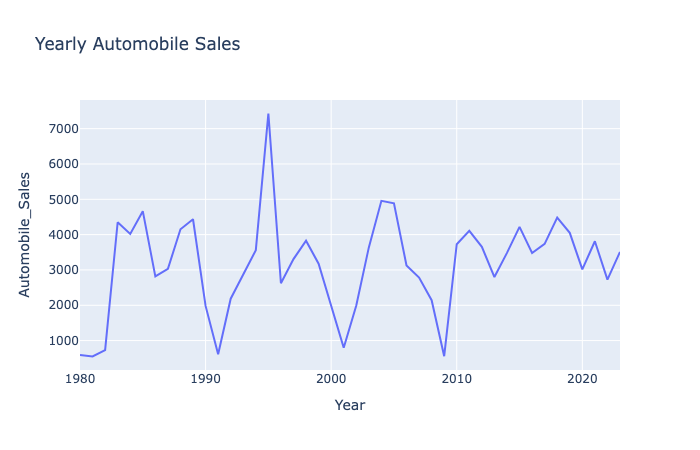

### 1.2 Plot 2 - Total Monthly Automobile Sales
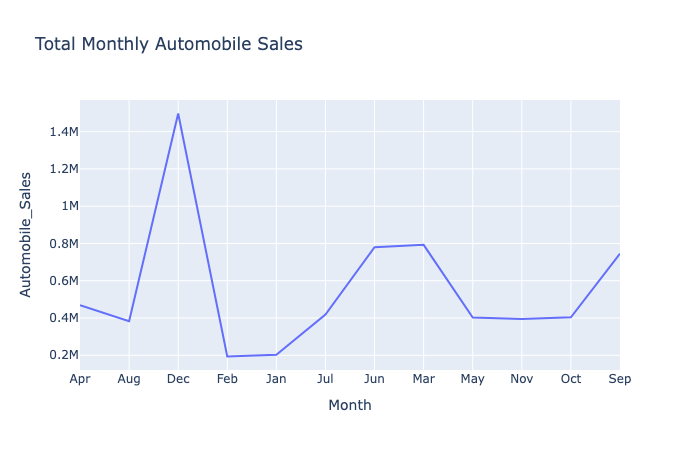

### 1.3 Plot 3 - Average Vehicles Sold By Vehicle Type (1980)
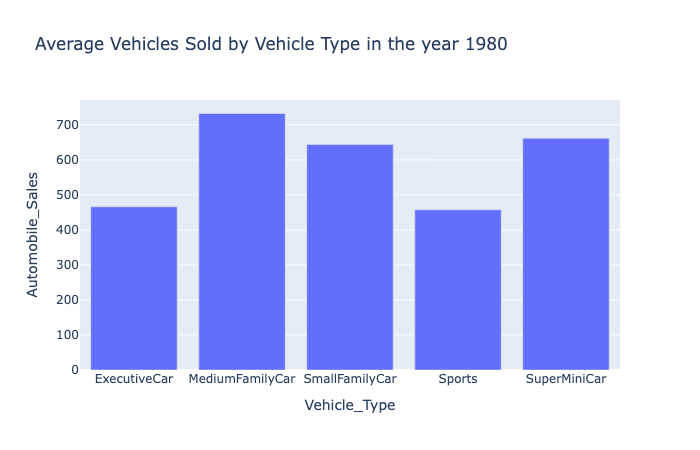

### 1.4 Plot 4 - Total Advertisement Expenditure for Each Vehicle
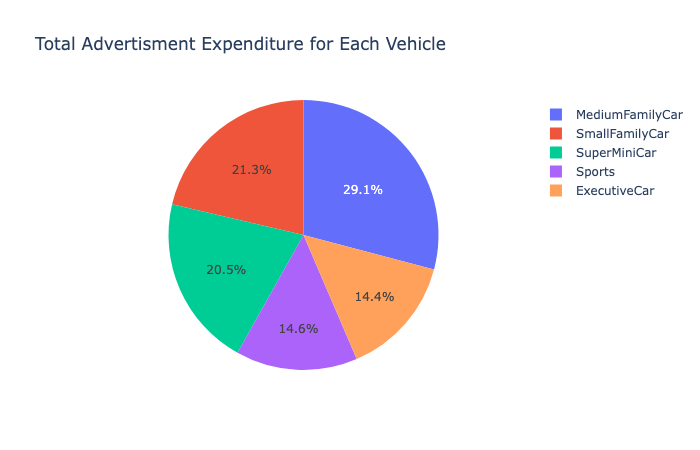

-------------------------------------------------------------------

## 2. Output - Recession Period Statistics Selection
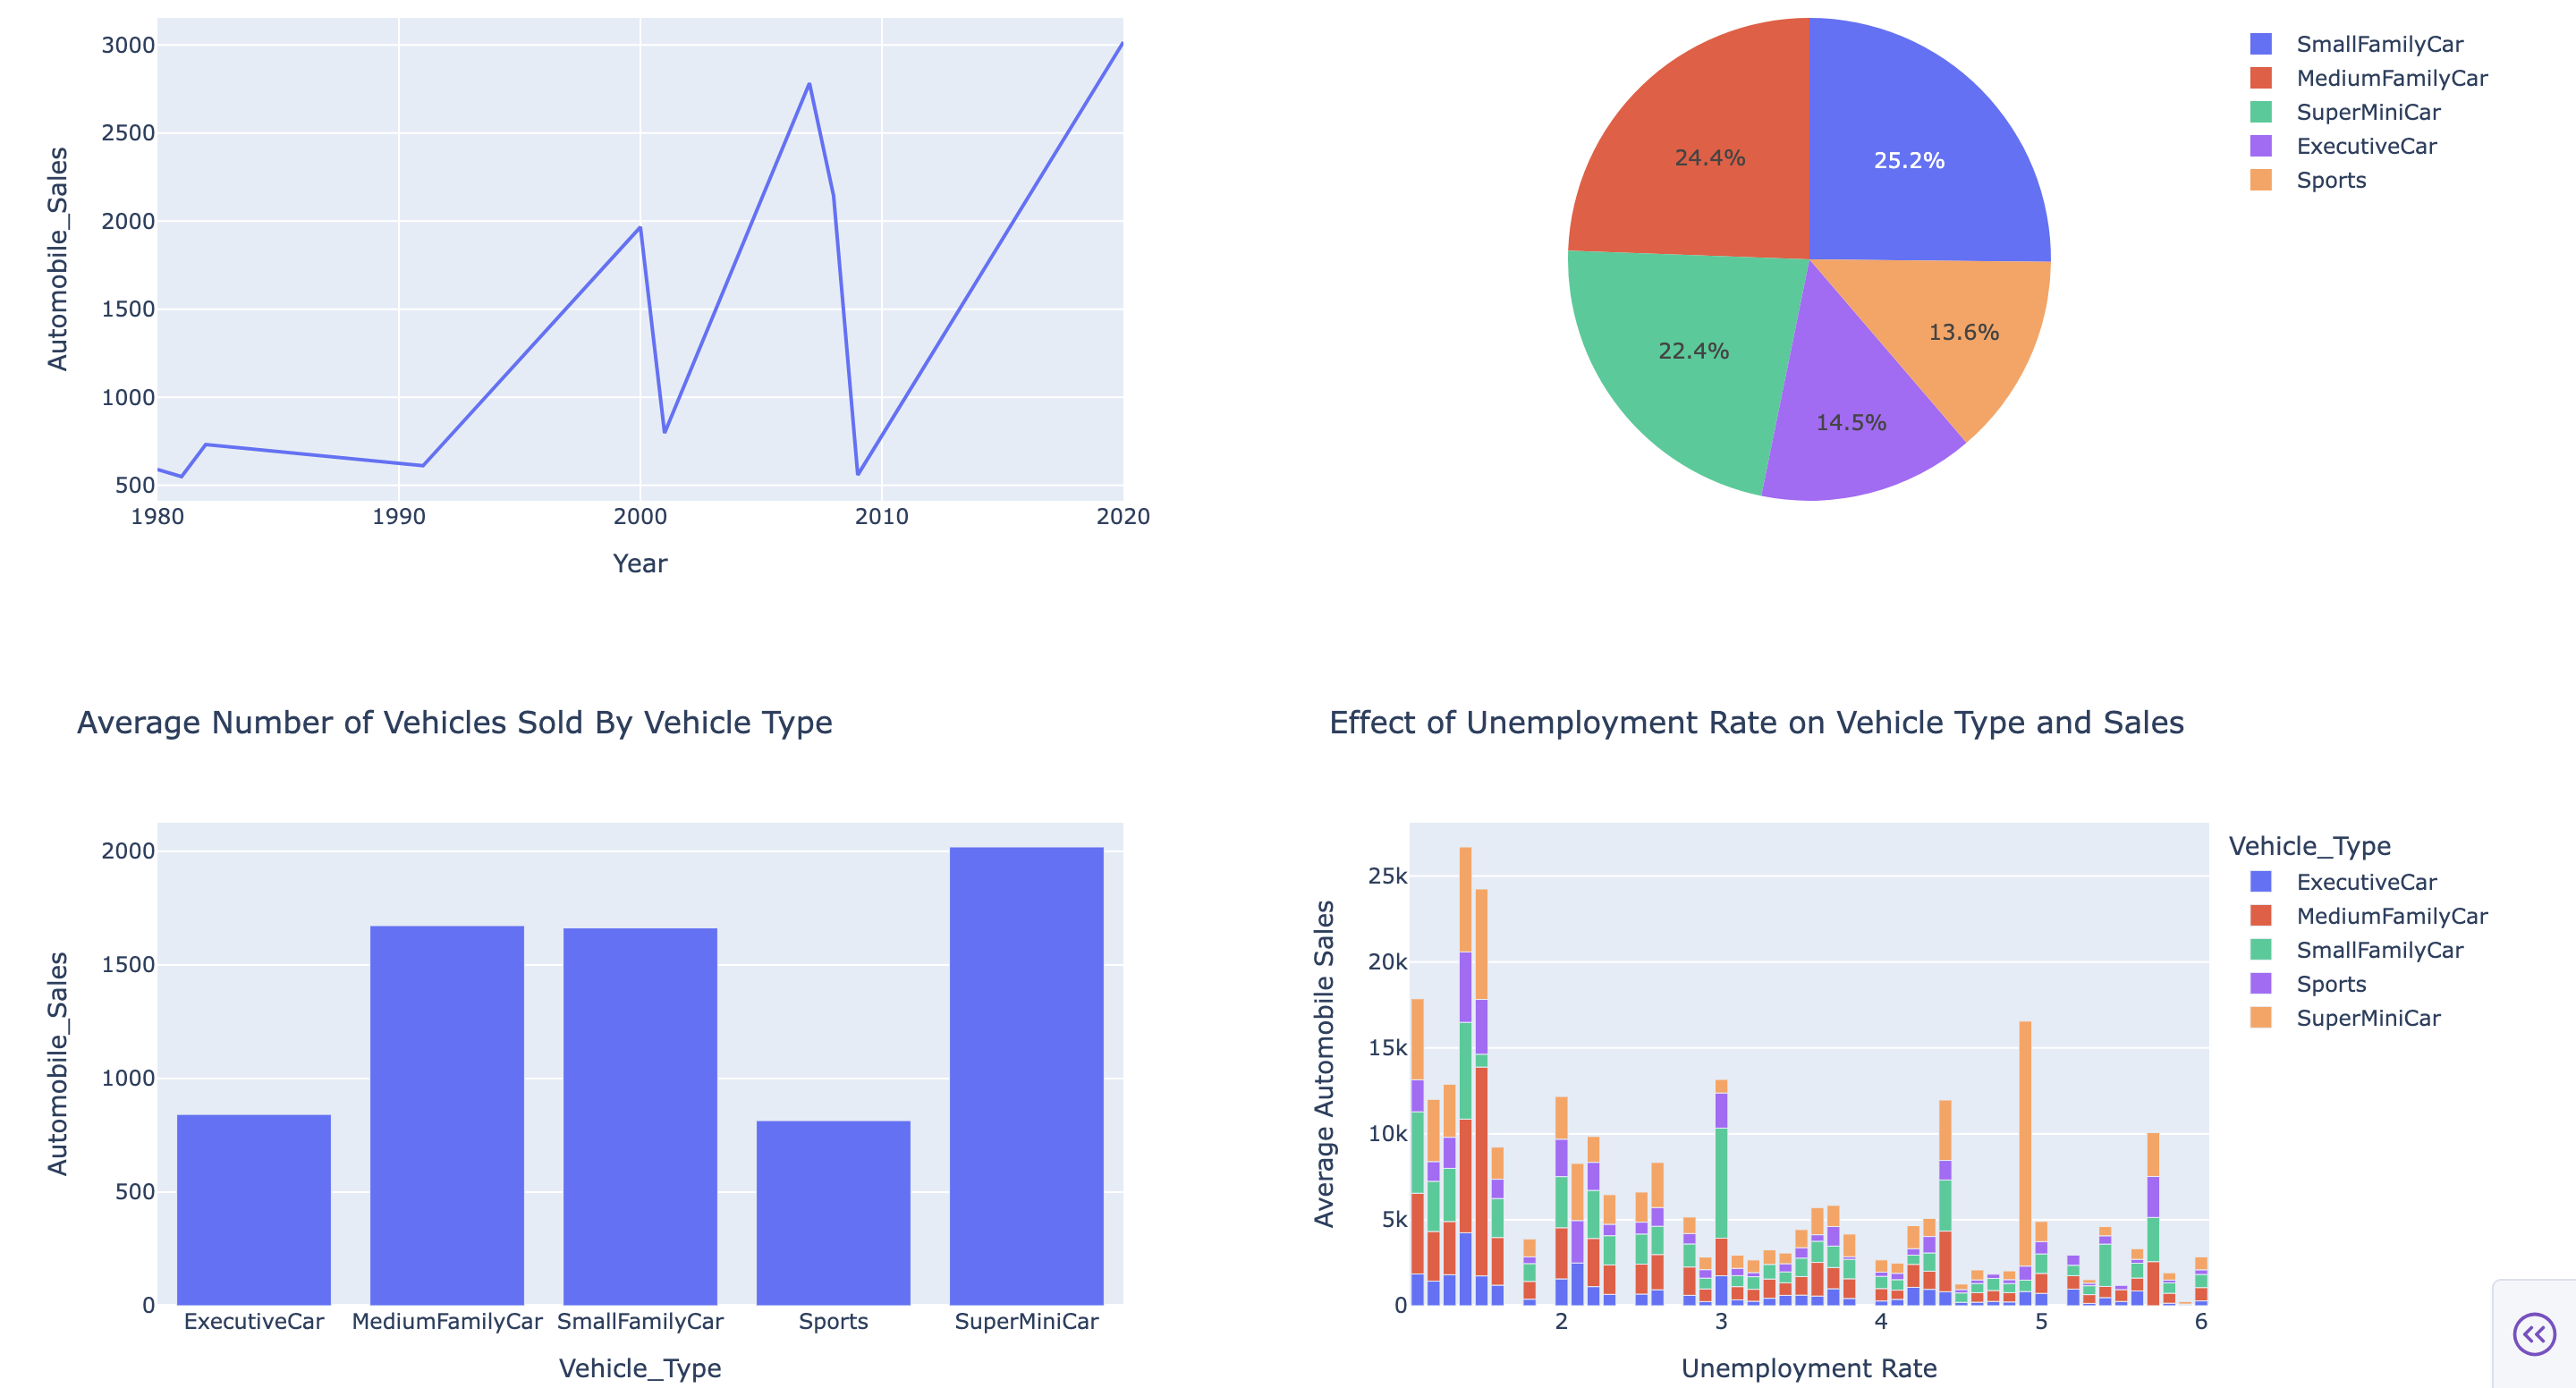

### 2.1 Plot 5 - Average Automobile Sales Fluctuation Over Recession Period
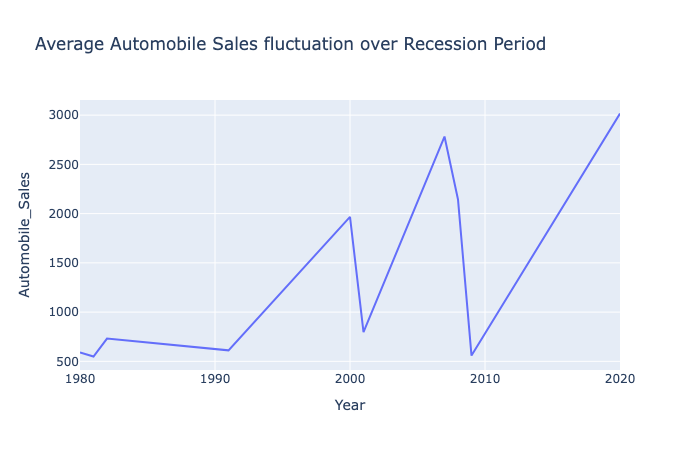

### 2.2 Plot 6 - Average Number of Vehicles Sold By Vehicle Type
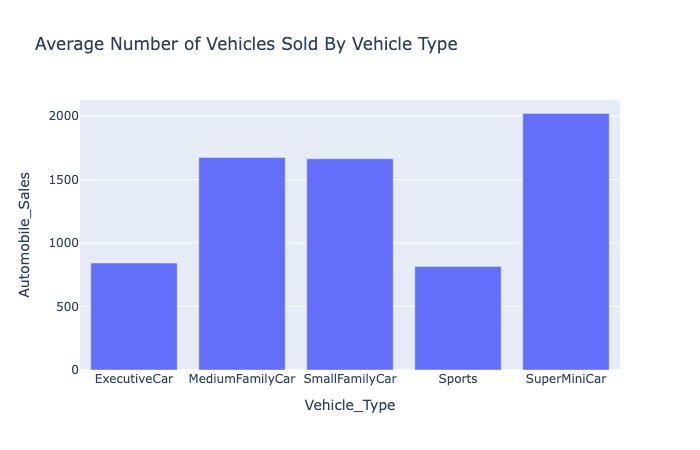

### 2.3 Plot 7 - Total Expenditure Share By Vehicle Type During Recessions
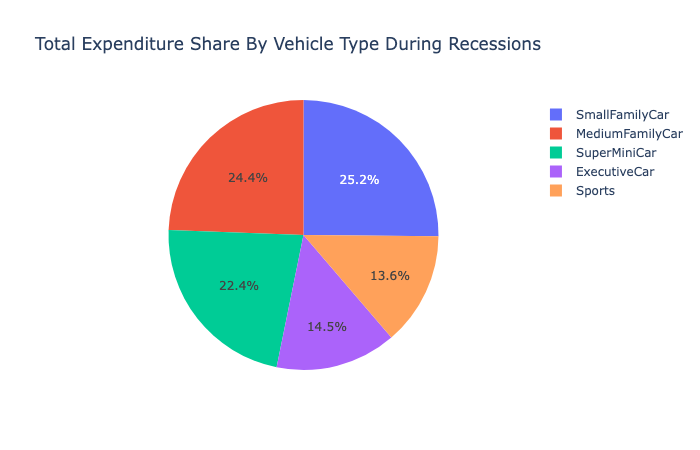

### 2.4 Plot 8 - Effect of Unemployment Rate on Vehicle Type and Sales
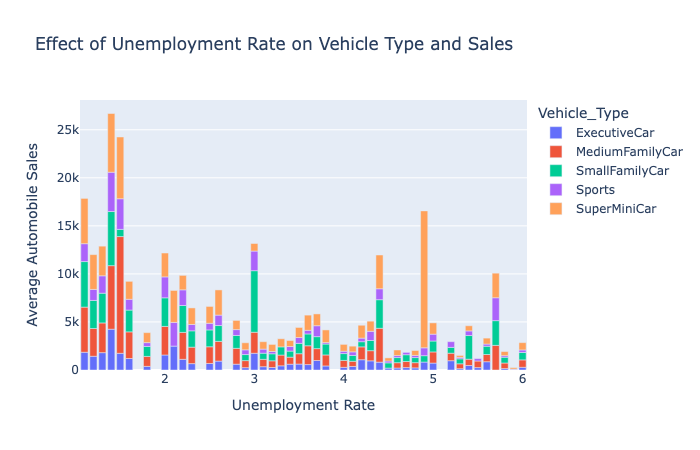